# Lab 1: Simple Object Detection and Benchmarking with OpenVINO

**Goals:**
- Run object detection using OpenVINO
- Understand inference flow
- Measure throughput and FPS

## Installation

Run the cell below once to install required libraries.

In [1]:
# Install required libraries (run once)
!pip install openvino openvino-dev opencv-python numpy matplotlib ipywidgets gradio

## Simple Pipeline

**Input Image** → **Preprocessing** → **OpenVINO Model** → **Detection Output** → **Bounding Boxes**

## Setup

Run from `1/` directory. Needs `utils.py` and `app_gradio.py` in same folder. Model downloads automatically if not present.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
from IPython.display import display

from utils import (
    download_person_vehicle_bike,
    load_atss_model,
    run_detection_atss,
    draw_boxes,
    benchmark_latency_ms,
    get_available_devices,
    check_device_latency,
)

MODEL_DIR = "models"
IMAGE_PATH = "media/sample_image-1.jpg"

# Download model if not present (run once)
download_person_vehicle_bike(MODEL_DIR)

devices = get_available_devices()
default_dev = "CPU" if "CPU" in devices else (devices[0] if devices else "CPU")
device_dd = widgets.Dropdown(options=devices, value=default_dev, description="Device:")
precision_dd = widgets.Dropdown(options=["FP32", "FP16"], value="FP16", description="Precision:")
load_out = widgets.Output()

def _load_atss(*args):
    global compiled_model, input_shape
    with load_out:
        load_out.clear_output(wait=True)
        compiled_model, xml_path = load_atss_model(MODEL_DIR, precision_dd.value, device_dd.value)
        input_shape = compiled_model.input(0).shape
        print(f"Loaded ATSS person-vehicle-bike ({precision_dd.value}) on {device_dd.value} | Input: {input_shape}")

device_dd.observe(_load_atss, names="value")
precision_dd.observe(_load_atss, names="value")
display(widgets.HBox([device_dd, precision_dd]))
display(load_out)
_load_atss()

Output()

## Device & precision (auto-reloads on change)

In [3]:
# Model loaded above. Change device/precision dropdown - it auto-reloads.

## Image Inference

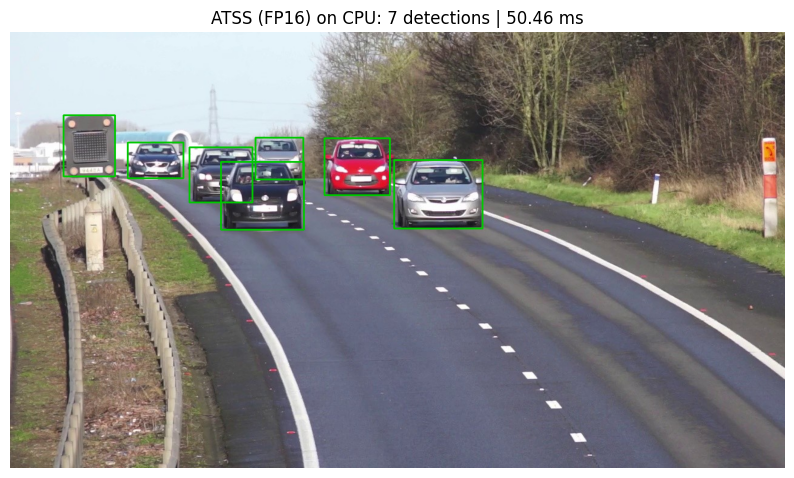

In [4]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

boxes, _, input_tensor = run_detection_atss(compiled_model, image, input_shape, target_classes=(0, 1), thresh=0.3)
result_img = draw_boxes(image, boxes)
latency_ms = benchmark_latency_ms(compiled_model, input_tensor, num_iter=50)
check_device_latency(device_dd.value, latency_ms, "atss")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"ATSS ({precision_dd.value}) on {device_dd.value}: {len(boxes)} detections | {latency_ms:.2f} ms")
plt.show()

## Optional: PyTorch to OpenVINO Conversion

For reference only. The main workflow uses pre-converted IR models. Use `convert_model()` and `ov.save_model()` to export PyTorch models to OpenVINO IR.

## Benchmarking: Inference Time by Precision

Single-image object detection. Average inference time (ms) for FP32, FP16, and INT8.

FP32 → 72.9 ms
FP16 → 84.9 ms
INT8 → 27.3 ms


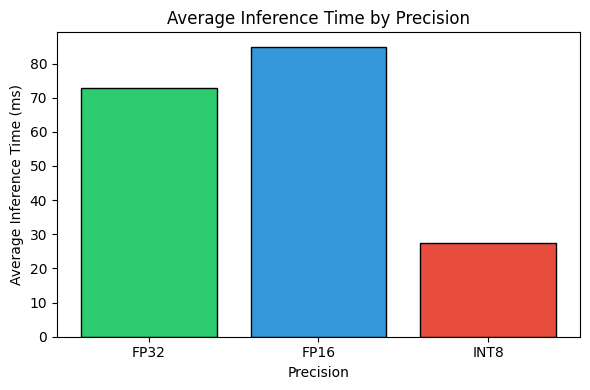

In [5]:
results = {}
for prec in ["FP32", "FP16", "INT8"]:
    try:
        compiled_p, _ = load_atss_model(MODEL_DIR, prec, device_dd.value)
        lat_ms = benchmark_latency_ms(compiled_p, input_tensor, num_iter=50)
        results[prec] = lat_ms
        print(f"{prec} → {lat_ms:.1f} ms")
    except FileNotFoundError:
        print(f"{prec} → (model not found)")
        results[prec] = 0
    except Exception as e:
        print(f"{prec} → Error: {e}")
        results[prec] = 0

precisions = [p for p in results if results[p] > 0]
vals = [results[p] for p in precisions]
if precisions:
    plt.figure(figsize=(6, 4))
    plt.bar(precisions, vals, color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black")
    plt.xlabel("Precision")
    plt.ylabel("Average Inference Time (ms)")
    plt.title("Average Inference Time by Precision")
    plt.tight_layout()
    plt.show()

## Launch Gradio app

Interactive demo with image selection, device, and precision.

In [6]:
from app_gradio import create_demo_atss
demo = create_demo_atss(MODEL_DIR)
demo.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


## Wrap-up

- OpenVINO simplifies deployment of object detection models
- The detection pipeline is straightforward: load → preprocess → infer → postprocess
- Lower precision (FP16, INT8) typically reduces inference time
- Pre-converted IR models keep the workflow simple and fast